In [ ]:
import os
import json
import time
import argparse
from typing import Tuple, Optional

import numpy as np
from scipy.optimize import minimize

#few and SEF imports
from few.waveform import GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import KerrEccEqFlux
from few.utils.geodesic import get_fundamental_frequencies
from scipy.interpolate import CubicSpline
from scipy.integrate import cumulative_trapezoid
from few.utils.constants import MTSUN_SI

from fastlisaresponse import ResponseWrapper
from lisatools.detector import EqualArmlengthOrbits
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from stableemrifisher.utils import generate_PSD, inner_product
from stableemrifisher.fisher import StableEMRIFisher
import matplotlib.pyplot as plt

from config_paris import Config, ObjectiveTracker
from misc import *

try:
    import cupy as cp
    xp=cp
except:
    xp=np
    print("CuPy not found, using NumPy instead. For GPU acceleration, please install CuPy.")

In [ ]:
# -----------------------------
# PARIS global context (picklable functions require module scope)
# -----------------------------..l
_PARIS_REF_CENTER = None          # type: Optional[np.ndarray]
_PARIS_SPREAD_SCALE = None        # type: Optional[float]
_PARIS_OBJECTIVE = None           # type: Optional[callable]
_PARIS_TARGET_KIND = None         # type: Optional[str]  # 'optimal_snr', 'optimal_snr_phase_max', 'phase_match', 'time_max'
# _PARIS_EARLY_STOP_HIT = False

# Fisher-parallelotope affine prior (primary for this script)
_PARIS_AFFINE_CENTER = None       # type: Optional[np.ndarray]
_PARIS_AFFINE_Q = None            # type: Optional[np.ndarray]
_PARIS_AFFINE_B = None            # type: Optional[np.ndarray]
_PARIS_DIM = None                 # type: Optional[int]
_PARIS_USE_ELLIPSE = True

cfg = Config()
# Target SNR for Fisher scaling
_TARGET_SNR = cfg._TARGET_SNR
base_dir = cfg.basedir

In [ ]:
def paris_prior_transform(u):
    """Prior transform using Fisher-parallelotope when configured.

    If affine parameters are set: theta = center + Q @ (b * t), with t = 2u-1.
    Otherwise falls back to multiplicative band around _PARIS_REF_CENTER.
    """
    u = np.asarray(u, dtype=float)
    if _PARIS_AFFINE_CENTER is not None and _PARIS_AFFINE_Q is not None and _PARIS_AFFINE_B is not None:
        center = _PARIS_AFFINE_CENTER
        Q = _PARIS_AFFINE_Q
        b = _PARIS_AFFINE_B
        dim = Q.shape[0]

        def map_one(u1):
            t = 2.0 * np.asarray(u1)[:dim] - 1.0
            return center + Q @ (b * t)

        if u.ndim == 1:
            theta = map_one(u)
            # if theta.shape[0] == 5:
            return _clip_physical_params_intrinsic(theta)
            # else:
            #     return check_and_clip_prior(theta, params_to_infer)
        else:
            out = np.zeros((u.shape[0], dim), dtype=float)
            for i in range(u.shape[0]):
                out[i] = map_one(u[i])
            return _clip_physical_params_intrinsic(out)
            # else:
            #     return check_and_clip_prior(out, params_to_infer)

    # Legacy multiplicative band (fallback)
    ref = _PARIS_REF_CENTER
    s = _PARIS_SPREAD_SCALE
    u = np.asarray(u)
    return ref * (1 - s + u * 2 * s)


def paris_inverse_prior_transform(params):
    """Inverse of paris_prior_transform.

    For affine Fisher mapping: t = diag(1/b) Q^T (theta - center), u = 0.5*(t+1).
    Falls back to multiplicative inverse if affine not configured.
    """
    theta = np.asarray(params, dtype=float)
    if _PARIS_AFFINE_CENTER is not None and _PARIS_AFFINE_Q is not None and _PARIS_AFFINE_B is not None:
        center = _PARIS_AFFINE_CENTER
        Q = _PARIS_AFFINE_Q
        b = _PARIS_AFFINE_B
        inv_b = 1.0 / b

        def inv_one(th):
            d = np.asarray(th) - center
            t = (Q.T @ d) * inv_b
            return 0.5 * (t + 1.0)

        if theta.ndim == 1:
            return inv_one(theta)
        out = np.zeros_like(theta, dtype=float)
        for i in range(theta.shape[0]):
            out[i] = inv_one(theta[i])
        return out

    ref = _PARIS_REF_CENTER
    s = _PARIS_SPREAD_SCALE
    return (theta / ref - (1 - s)) / (2 * s)


def paris_log_density(params):
    """Top-level log-density (score) wrapper without early-stop.

    - Receives physical parameters (after prior_transform) per parismc contract.
    - Returns a scalar/array of scores (larger is better).
    """
    params = np.asarray(params)

    def eval_one(x):
        try:
            val = float(_PARIS_OBJECTIVE(x))
        except Exception:
            return float('-inf')
        return val

    if params.ndim == 1:
        return eval_one(params)

    out = np.zeros(params.shape[0], dtype=float)
    for i in range(params.shape[0]):
        out[i] = eval_one(params[i])
    return out

In [ ]:
def build_waveform_response(T: float, dt: float, use_gpu: bool = False) -> ResponseWrapper:
    """Create a LISA ResponseWrapper consistent with existing modules."""

    sum_kwargs = dict(pad_output=False, odd_len=True)
    
    waveform_model = GenerateEMRIWaveform(SuperKludgeWaveform, sum_kwargs=sum_kwargs, return_list=False,use_gpu=use_gpu)

    t0 = 10000.0
    tdi_gen = "2nd generation"
    order = 20
    index_lambda = 8  # phiS
    index_beta = 7    # qS

    response = ResponseWrapper(
        waveform_gen=waveform_model,
        Tobs=T,
        t0=t0,
        dt=dt,
        index_lambda=index_lambda,
        index_beta=index_beta,
        flip_hx=True,
        is_ecliptic_latitude=False,
        remove_garbage="zero",
        orbits=EqualArmlengthOrbits(use_gpu=use_gpu),
        force_backend = "cuda12x" if use_gpu else "cpu",
        order=order,
        tdi=tdi_gen,
        tdi_chan="AET",
    )

    print("[INFO] Finished loading modules and building ResponseWrapper")
    return response

def prepare_true_waveform(signal_row: np.ndarray, emri_kwargs: dict, add_kwargs: dict, use_gpu: bool = False):
    """
    Build fiducial 1PA waveform, PSD, and FFT from a signal parameter row.
    signal_row columns:
      [m1, m2, a, p0, e0, Y0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    """
    (
        m1, m2, a, p0, e0, Y0,
        dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0
    ) = signal_row

    waveform_response = build_waveform_response(T=emri_kwargs['T'], dt=emri_kwargs['dt'], use_gpu=use_gpu)

    chi2 = add_kwargs.get('chi2')
    deviation_included = add_kwargs.get('deviation_included', True)
    #add_kwargs['evolve_1PA'] = True
    evolve_1PA = add_kwargs['evolve_1PA']
    evolve_primary = add_kwargs.get('evolve_primary', False)
    evolve_2PA = add_kwargs.get('evolve_2PA',False)
    dev_1 = add_kwargs.get('dev_1')
    dev_2 = add_kwargs.get('dev_2')
    dt = emri_kwargs['dt']
    T=emri_kwargs['T']

    wave_params = [
        m1, m2, a, p0, e0, Y0,
        dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,chi2, evolve_1PA, evolve_primary, evolve_2PA, deviation_included, dev_1, dev_2
    ]
    # emri_kwargs = {"T": T, "dt": dt, 'chi2': chi2, 'evolve_1PA': evolve_1PA, 'evolve_primary': evolve_primary,
    #                 'evolve_2PA': evolve_2PA,'deviation_included': deviation_included,'dev_1': dev_1, 'dev_2': dev_2}

    waveform_true = xp.array(waveform_response(*wave_params, **emri_kwargs))
    print("[INFO] Finished generating true waveform")
    

    channels = [A1TDISens, E1TDISens, T1TDISens]
    noise_kwargs = [{"sens_fn": ch} for ch in channels]
    PSD_funcs = generate_PSD(
        waveform=waveform_true,
        dt=dt,
        noise_PSD=get_sensitivity,
        channels=channels,
        noise_kwargs=noise_kwargs,
        use_gpu=use_gpu,
    )

    # Verify SNR level (grid builder normalized dist to target PA2 SNR already)
    PSD_funcs_ = xp.array(PSD_funcs)

    # print("type check - waveform_true:", type(waveform_true), "PSD_funcs:", type(PSD_funcs_), "dt:", type(dt))
    print("shape check - waveform_true:", xp.shape(waveform_true), "PSD_funcs:", xp.shape(PSD_funcs_))
    snr_2 = inner_product(waveform_true, waveform_true, PSD_funcs_, dt, use_gpu=use_gpu)
    #if hasattribute get u
    snr = np.sqrt(snr_2.get()) if hasattr(snr_2, "get") else np.sqrt(snr_2)
    print(f"[TRUE] SNR: {snr:.6f}")
    N_fiducial = len(waveform_true[0])
    
    waveform_true_fft = compute_fft_with_windowing(waveform_true, dt, N_fiducial, use_gpu=use_gpu, n_channels=3)
    
    print("[INFO] Finished preparing true waveform (GPU)")
    freq=np.fft.rfftfreq(N_fiducial, dt)

    return {
        'm1': m1, 'm2': m2, 'a': a, 'p0': p0, 'e0': e0, 'Y0': Y0,
        'dist': dist, 'qS': qS, 'phiS': phiS, 'qK': qK, 'phiK': phiK,
        'Phi_phi0': Phi_phi0, 'Phi_theta0': Phi_theta0, 'Phi_r0': Phi_r0,
        'dt': dt, 'T': T, 'chi2': chi2,
        'dev_1': dev_1, 'dev_2': dev_2,
        'waveform_response': waveform_response,
        'PSD_funcs': PSD_funcs_,
        'waveform_true_fft': waveform_true_fft,
        'N_fiducial': N_fiducial,
        'snr': snr,
        'delta_f': freq[1]-freq[0],
        'freq': freq
    }


In [ ]:
def objective_factory(target_func: str,
                      ctx: dict,
                      phase_max: bool = False,
                      use_gpu_for_snr: bool = True,
                      infer_deviation_included: bool = False,
                      only_intrinsic_params: bool = False,
                      add_kwargs: dict = None) -> callable:
    """
    Build a score(theta) where larger is better for all targets.
    - 'optimal_snr' and 'optimal_snr_phase_max': score = optimal SNR (maximize)
    - 'phase_match': score = -phase_diff_metric (maximize score => minimize phase diff)
    """
    # Only needed for SNR-based objective
    if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        fixed = {
            'waveform_response': ctx['waveform_response'],
            'PSD': ctx['PSD_funcs'],
            'dt': ctx['dt'],
            'T': ctx['T'],
            'N_fiducial': ctx['N_fiducial'],
            'waveform_true_fft': ctx['waveform_true_fft'],
            'xp': np,'delta_f': ctx['delta_f'],
            'use_gpu': bool(use_gpu_for_snr),
        }

    def score_optimal_snr(theta: np.ndarray) -> float:
        if only_intrinsic_params == True:
            if infer_deviation_included == False:
                m1, m2, a, p0, e0 = theta
                add_kwargs['evolve_1PA'] = False
                val = calculate_detection_snr_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    maximize_phase=bool(phase_max),
                    **fixed,)
                
            else:
                m1, m2, a, p0, e0, dev_1, dev_2 = theta
                add_kwargs['evolve_1PA'] = False
                add_kwargs['deviation_included'] = False
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                val = calculate_detection_snr_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    maximize_phase=bool(phase_max),
                    **fixed,)

        else:
            if infer_deviation_included:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = theta
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                add_kwargs['evolve_1PA'] = False
                add_kwargs['deviation_included'] = False
                val = calculate_detection_snr_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs,
                    maximize_phase=bool(phase_max),
                    **fixed)
               # print(val, 'param', repr(theta))
                
            else:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = theta
                add_kwargs['evolve_1PA'] = False
                val = calculate_detection_snr_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs,
                    maximize_phase=bool(phase_max),
                    **fixed)
                #print(val, 'param', repr(theta))
        # Score is the SNR itself (maximize)
        return float(val)
    
    def score_time_max(theta: np.ndarray) -> float:
        if only_intrinsic_params == True:
            if infer_deviation_included == False:
                m1, m2, a, p0, e0 = theta
                add_kwargs['evolve_1PA'] = False
                val = calculate_time_max_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    **fixed,)
                
            else:
                m1, m2, a, p0, e0, dev_1, dev_2 = theta
                add_kwargs['evolve_1PA'] = False
                add_kwargs['deviation_included'] = False
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                val = calculate_time_max_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],ctx['qS'],ctx['phiS'], ctx['qK'], ctx['phiK'], 
                    ctx['Phi_phi0'], ctx['Phi_theta0'], ctx['Phi_r0'],add_kwargs,
                    **fixed,)

        else:
            if infer_deviation_included:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0,dev_1,dev_2 = theta
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                add_kwargs['evolve_1PA'] = False
                add_kwargs['deviation_included'] = False
                val = calculate_time_max_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs,
                    **fixed)
               # print(val, 'param', repr(theta))
                
            else:
                m1, m2, a, p0, e0,qS,phiS,Phi_phi0,Phi_r0 = theta
                add_kwargs['evolve_1PA'] = False
                val = calculate_time_max_0pa_vs_1pa(
                    m1, m2, a, p0, e0, ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    Phi_phi0, ctx['Phi_theta0'], Phi_r0,add_kwargs,**fixed)
                #print(val, 'param', repr(theta))
        # Score is the SNR itself (maximize)
        return float(val)

    # Phase-match uses trajectory frequency metric from phase-match.py logic
    # Here we re-implement a light-weight metric using FEW's fundamental frequencies.
  

    # Precompute 1PA Omega_phi(t) interpolation and frequency weights
    # Build 1PA trajectory from the signal row
    SK_traj_1PA = EMRIInspiral(func=KerrEccEqFlux)  # For 0PA vs 1PA metric we still compare to the same t-grid
    # Note: We only need 1PA ref already embedded in ctx? We rebuild Omega_phi_1PA curve here robustly
    # However ctx doesn’t include (t,p,e,x) of 1PA; reconstruct for phase metric
    from few.trajectory.inspiral import EMRIInspiral as EMRIInspiralFull
    from few.trajectory.ode.flux import SuperKludgeFlux

    SK_traj_true = EMRIInspiralFull(func=SuperKludgeFlux)

    # do we need to implement it inside the function
    add_kwargs["evolve_1PA"] = True
    traj_ref = SK_traj_true.get_inspiral(
        ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0'], ctx['Y0'],
        ctx['chi2'], add_kwargs["evolve_1PA"], add_kwargs['evolve_primary'], add_kwargs['evolve_2PA'],add_kwargs['deviation_included']
        ,add_kwargs['dev_1'],add_kwargs['dev_2'],Phi_phi0 = ctx['Phi_phi0'], Phi_theta0 = ctx['Phi_theta0'], Phi_r0 = ctx['Phi_r0'],
        T=ctx['T'], dt=ctx['dt'], err=1e-11, DENSE_STEPPING=False,
        buffer_length=1000, integrate_backwards=False,
        max_step_size=None,
    )
    t_ref, p_ref, e_ref, x_ref = traj_ref[0], traj_ref[1], traj_ref[2], traj_ref[3]
    Omega_phi_ref, _, _ = get_fundamental_frequencies(ctx['a'], p_ref, e_ref, x_ref)
    # Common time grid and 1PA omega interpolation
    t_common = np.linspace(t_ref.min(), t_ref.max(), 1000)
    Omega_phi_1PA_interp = CubicSpline(t_ref, Omega_phi_ref)(t_common)

    # Frequency weighting w(t) ~ sum 1/S_n(f_gw)
    m_mode = 2
    Msec = (ctx['m1'] + ctx['m2']) * MTSUN_SI
    Omega2_SI = Omega_phi_1PA_interp / Msec
    f_gw = m_mode * Omega2_SI / (2.0 * np.pi)
    w = np.zeros_like(f_gw)
    for ch in (A1TDISens, E1TDISens, T1TDISens):
        Sn = get_sensitivity(f_gw, sens_fn=ch)
        Sn = np.maximum(Sn, 1e-60)
        w += 1.0 / Sn

    def phase_metric_for_theta(theta: np.ndarray) -> float:
        # Supports both 0PA against 1PA reference
        if only_intrinsic_params == True:
            if infer_deviation_included == False:
                m1, m2, a, p0, e0 = theta
                add_kwargs['deviation_included'] = False
                add_kwargs['evolve_1PA'] = False
            else:
                m1, m2, a, p0, e0, dev_1, dev_2 = theta
                add_kwargs['dev_1'] = dev_1
                add_kwargs['dev_2'] = dev_2
                add_kwargs['deviation_included'] = True
                add_kwargs['evolve_1PA'] = False
        else:
            print("For entrinsic parameters, phase metric is not supported. Returning inf.")
            assert False, "For entrinsic parameters, phase metric is not supported. Returning inf."

        # Build trajectory for the chosen template order (0PA or 1PA) without 2PA
        SK_traj_tmpl = EMRIInspiral(func=KerrEccEqFlux)

        traj_0 = SK_traj_tmpl.get_inspiral(
            m1, m2, a, p0, e0, ctx['Y0'], add_kwargs['chi2'], add_kwargs['evolve_1PA'], add_kwargs['evolve_primary'], add_kwargs['evolve_2PA'],
            add_kwargs['deviation_included'],add_kwargs['dev_1'],add_kwargs['dev_2'],
            Phi_phi0 = ctx['Phi_phi0'], Phi_theta0 = ctx['Phi_theta0'], Phi_r0 = ctx['Phi_r0'],
        T=ctx['T'], dt=ctx['dt'], err=1e-11, DENSE_STEPPING=False,
        buffer_length=1000, integrate_backwards=False,
        max_step_size=None,)

        t0, p0_arr, e0_arr, x0 = traj_0[0], traj_0[1], traj_0[2], traj_0[3]
        Omega_phi_0, _, _ = get_fundamental_frequencies(a, p0_arr, e0_arr, x0)
        # Interpolate to common grid
        Omega_phi_0_interp = CubicSpline(t0, Omega_phi_0)(t_common)
        # Weighted phase difference metric
        dOmega_geo = Omega_phi_0_interp - Omega_phi_1PA_interp
        dOmega_SI = dOmega_geo / Msec
        dphi = np.concatenate([[0.0], m_mode * cumulative_trapezoid(dOmega_SI, t_common)])
        num = np.trapezoid(w * dphi**2, t_common)
        den = np.trapezoid(w, t_common)
        res = np.sqrt(num / den)

        # theta_repr = "np.array(" + np.array2string(                   # Print theta as a copyable NumPy array with high precision
        #     theta,
        #     formatter={'float_kind': lambda x: f"{x:.12g}"},
        #     separator=', '
        # ) + ")"
        # print(f"{res:.6g}", 'param', theta_repr)
        return res

    def score_phase_match(theta: np.ndarray) -> float:
        # Lower phase difference should be better => use negative for a larger-is-better score
        return -float(phase_metric_for_theta(theta))

    if target_func in ('optimal_snr', 'optimal_snr_phase_max'):
        return score_optimal_snr
    elif target_func == 'phase_match':
        return score_phase_match
    elif target_func == 'time_max':
        return score_time_max
    else:
        raise ValueError(f"Unknown target_func: {target_func}")
        

In [ ]:
def nelder_mead_optimize(theta0: np.ndarray, objective, maxiter: int = 300, xatol: float = 1e-10, fatol: float = 1e-12): #300
    res = minimize(
        objective,
        theta0,
        method='Nelder-Mead',
        options={'maxiter': maxiter, 'maxfev': 300, 'xatol': xatol, 'fatol': fatol},
    )
    return res

In [ ]:
def run_paris(ndim: int,
              prior_center: np.ndarray,
              score_func,
              spread_scale: float,
              savepath: str,
              seed_cloud: int = 1000,
              seed_jitter: float = 1e-10,
              target_kind: str = None,
              lhs_save_dir: Optional[str] = None,
              affine_Q: Optional[np.ndarray] = None,
              affine_b: Optional[np.ndarray] = None,
              use_ellipse: bool = True):
    """Run PARIS sampler maximizing a score with a local prior around starting point.

    Notes on pickling:
    - parismc pickles the sampler, including log_density_func and prior_transform.
    - We therefore use top-level functions (paris_log_density/prior_transform) and
      set their behavior via module-level globals.
    """
    import parismc

    os.makedirs(savepath, exist_ok=True)

    # Configure global context for top-level callables
    global _PARIS_REF_CENTER, _PARIS_SPREAD_SCALE, _PARIS_OBJECTIVE, _PARIS_TARGET_KIND, _PARIS_EARLY_STOP_HIT
    global _PARIS_AFFINE_CENTER, _PARIS_AFFINE_Q, _PARIS_AFFINE_B, _PARIS_DIM
    global _PARIS_USE_ELLIPSE
    _PARIS_REF_CENTER = np.asarray(prior_center, dtype=float).copy()
    _PARIS_SPREAD_SCALE = float(spread_scale)
    _PARIS_OBJECTIVE = score_func
    _PARIS_TARGET_KIND = target_kind
    _PARIS_EARLY_STOP_HIT = False
    _PARIS_USE_ELLIPSE = bool(use_ellipse)

    # Configure Fisher-affine prior if provided
    if affine_Q is not None and affine_b is not None:
        _PARIS_AFFINE_CENTER = np.asarray(prior_center, dtype=float).copy()
        _PARIS_AFFINE_Q = np.asarray(affine_Q, dtype=float).copy()
        _PARIS_AFFINE_B = np.asarray(affine_b, dtype=float).copy()
        _PARIS_DIM = int(_PARIS_AFFINE_Q.shape[0])
    else:
        _PARIS_AFFINE_CENTER = None
        _PARIS_AFFINE_Q = None
        _PARIS_AFFINE_B = None
        _PARIS_DIM = None

    # Initialize sampler
    n_seed = 10
    sigma = 1e-3
    init_cov_list = [sigma**2 * np.eye(ndim) for _ in range(n_seed)]
    config = parismc.SamplerConfig(
        merge_confidence=0.9,
        alpha=1000,
        #latest_prob_index=1000,
        trail_size=int(1e3),
        boundary_limiting=True,
        use_beta=True,
        integral_num=int(1e5),
        gamma=100,
        exclude_scale_z=np.inf,
        use_pool=False,
        cov_jitter=seed_jitter,  
      #  n_pool=36,
    )

    sampler = parismc.Sampler(
        ndim=ndim,
        n_seed=n_seed,
        log_density_func=paris_log_density,
        init_cov_list=init_cov_list,
        prior_transform=paris_prior_transform,
        config=config,
    )

    # Seed cloud in full unit cube; rely on Fisher-affine prior_transform for mapping
    unit_center = np.full(ndim, 0.5)
    center_val = float(paris_log_density(paris_prior_transform(unit_center.reshape(1, -1)))[0])

    point_blocks = [unit_center.reshape(1, -1)]
    log_blocks = [np.array([center_val])]

    n_samples = max(0, int(seed_cloud) - 1)
    if n_samples > 0:
        try:
            from smt.sampling_methods import LHS
        except ImportError as exc:
            raise RuntimeError(
                "smt.sampling_methods.LHS is required for PARIS seeding; install `smt` or ``pip install smt``"
            ) from exc

        xlimits = np.column_stack([
            np.zeros(ndim, dtype=float),
            np.ones(ndim, dtype=float),
        ])
        sampling = LHS(xlimits=xlimits)
        lhs_points = np.clip(sampling(n_samples), 0.0, 1.0)

        if lhs_points.ndim == 1:  # defensive: ensure (n, ndim)
            lhs_points = lhs_points.reshape(1, -1)

        # Require Fisher-affine mapping to be present
        if _PARIS_AFFINE_Q is None or _PARIS_AFFINE_B is None:
            raise RuntimeError("Fisher-affine prior is required for LHS seeding but is not set.")

        n_before = lhs_points.shape[0]
        if _PARIS_USE_ELLIPSE:
            # Fisher-ellipse truncation: keep points with ||t|| <= 1 where t = 2u-1
            t = 2.0 * lhs_points - 1.0
            keep_mask = np.sum(t * t, axis=1) <= 1.0
            lhs_points = lhs_points[keep_mask]
            n_after = lhs_points.shape[0]
            if n_after <= 0:
                raise RuntimeError("No LHS points remain after Fisher-ellipse truncation.")
            print(f"[LHS] before: {n_before}, after ellipse: {n_after}")
        else:
            print(f"[LHS] before: {n_before}, after ellipse: {n_before} (box)")

        theta_points = paris_prior_transform(lhs_points)
        theta_min = np.min(theta_points, axis=0)
        theta_max = np.max(theta_points, axis=0)
        print(f"[LHS] theta_min: {repr(theta_min)}")
        print(f"[LHS] theta_max: {repr(theta_max)}")        

        lhs_vals = paris_log_density(paris_prior_transform(lhs_points))

        point_blocks.append(lhs_points)
        log_blocks.append(np.asarray(lhs_vals, dtype=float).reshape(-1))

    external_lhs_points = np.vstack(point_blocks)
    external_lhs_log_densities = np.concatenate(log_blocks)

    if lhs_save_dir:
        os.makedirs(lhs_save_dir, exist_ok=True)
        np.save(os.path.join(lhs_save_dir, 'lhs_points.npy'), np.asarray(external_lhs_points, dtype=float))
        np.save(os.path.join(lhs_save_dir, 'lhs_log_densities.npy'), np.asarray(external_lhs_log_densities, dtype=float))

    max_idx = int(np.argmax(external_lhs_log_densities))
    max_point = external_lhs_points[max_idx]
    fallback_point = paris_prior_transform(max_point)
    fallback_score = float(external_lhs_log_densities[max_idx])
    sampler._fallback_best_point = np.asarray(fallback_point, dtype=float)
    sampler._fallback_best_score = fallback_score

    try:
        sampler.run_sampling(
            num_iterations=3000,
            savepath=savepath,
            print_iter=100,
            external_lhs_points=external_lhs_points,
            external_lhs_log_densities=external_lhs_log_densities,
        )
    except Exception as exc:
        print(f"[WARN] PARIS sampling failed: {exc}")
    return sampler, paris_prior_transform, external_lhs_points


[INFO] Finished loading modules and building ResponseWrapper
[INFO] Finished generating true waveform
shape check - waveform_true: (3, 788953) PSD_funcs: (3, 394476)
[TRUE] SNR: 27.003556
[INFO] Finished preparing true waveform (GPU)
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000000.0), np.float64(10000.0), np.float64(0.9), np.float64(28.5813146), np.float64(0.5), np.float64(1.0), np.float64(33.1765439), np.float64(1.04719755), np.float64(0.785398163), np.float64(0.628318531), np.float64(0.523598776), np.float64(0.1), np.float64(0.2), np.float64(0.3), 0.95, False, False, False, True, 0.0, 0.0)
SNR:  31.076691816704095
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000000.0), np.float64(10000.0), np.float64(0.9), np.float64(28.5813146), np.float64(0.5), np.float64(1.0), np.float64(33.1765439), np.float64(1.04719755), np.float64(0.785398163), np.float64(0.628318531

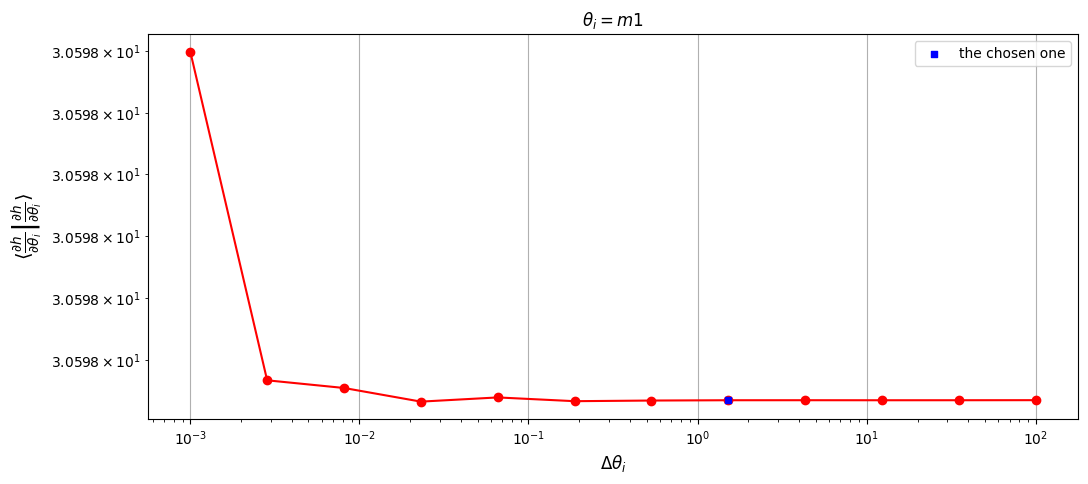

Gamma_ii for m2: 49573.23891505052
Gamma_ii for m2: 49573.23891184177
Gamma_ii for m2: 49573.2389141831
Gamma_ii for m2: 49573.23890372322
Gamma_ii for m2: 49573.23889443878
Gamma_ii for m2: 49573.23894507847
Gamma_ii for m2: 49573.23897546822
Gamma_ii for m2: 49573.238950399515
Gamma_ii for m2: 49573.24021238574
Gamma_ii for m2: 49573.240891095054
Gamma_ii for m2: 49573.25038926953
Gamma_ii for m2: 49573.26808142871
[np.float64(6.472742774109325e-11), np.float64(4.722972418084671e-11), np.float64(2.1099852496376684e-10), np.float64(1.872873805482704e-10), np.float64(1.021512636535599e-09), np.float64(6.130274061106371e-10), np.float64(5.056903399083829e-10), np.float64(2.5457005012304142e-08), np.float64(1.3691041841373908e-08), np.float64(1.9159878366496777e-07), np.float64(3.56889102980364e-07)]
1


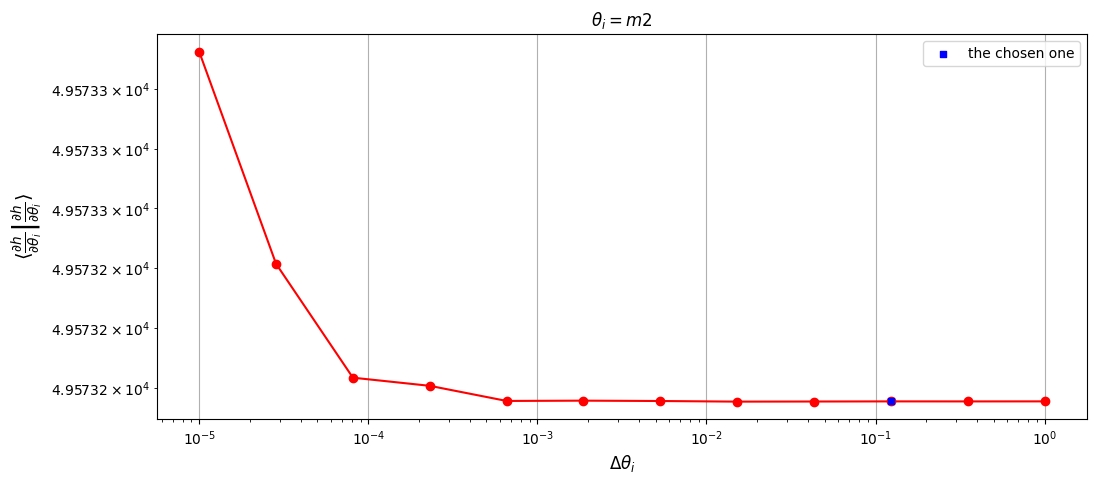

Gamma_ii for a: 63835597762.63597
Gamma_ii for a: 63835604945.76845
Gamma_ii for a: 63835285742.00124
Gamma_ii for a: 63835577701.81349
Gamma_ii for a: 63835330164.342995
Gamma_ii for a: 63835874976.35002
Gamma_ii for a: 63831915471.36266
Gamma_ii for a: 63878545104.10984
Gamma_ii for a: 63809952563.52122
Gamma_ii for a: 63805892810.49778
Gamma_ii for a: 64129783155.90529
Gamma_ii for a: 65677827464.913956
[np.float64(1.1252548609681184e-07), np.float64(5.00042826618477e-06), np.float64(4.573622151772831e-06), np.float64(3.877750296894372e-06), np.float64(8.534574128239252e-06), np.float64(6.203017656793445e-05), np.float64(0.000729973305922665), np.float64(0.0010749505027501923), np.float64(6.362661573430036e-05), np.float64(0.005050544839986472), np.float64(0.023570272780957236)]
0


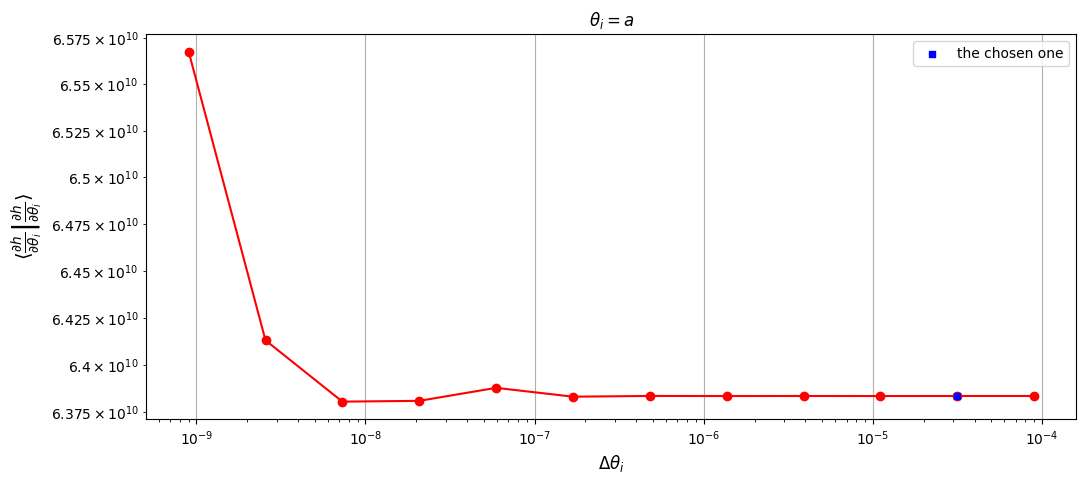

Gamma_ii for p0: 137178838468.12105
Gamma_ii for p0: 137178836992.561
Gamma_ii for p0: 137178840356.18788
Gamma_ii for p0: 137178841441.1202
Gamma_ii for p0: 137178941267.51312
Gamma_ii for p0: 137178854215.102
Gamma_ii for p0: 137178802051.788
Gamma_ii for p0: 137178849213.99
Gamma_ii for p0: 137180437705.54543
Gamma_ii for p0: 137181399926.82536
Gamma_ii for p0: 137174732088.92285
Gamma_ii for p0: 137165419111.14784
[np.float64(1.0756469989718446e-08), np.float64(2.452001247493654e-08), np.float64(7.908889597069477e-09), np.float64(7.277093116967958e-07), np.float64(6.345905979142529e-07), np.float64(3.8025783306466934e-07), np.float64(3.4380082849024677e-07), np.float64(1.1579577831859537e-05), np.float64(7.0142255469838294e-06), np.float64(4.860835374687813e-05), np.float64(6.7895959749612e-05)]
2


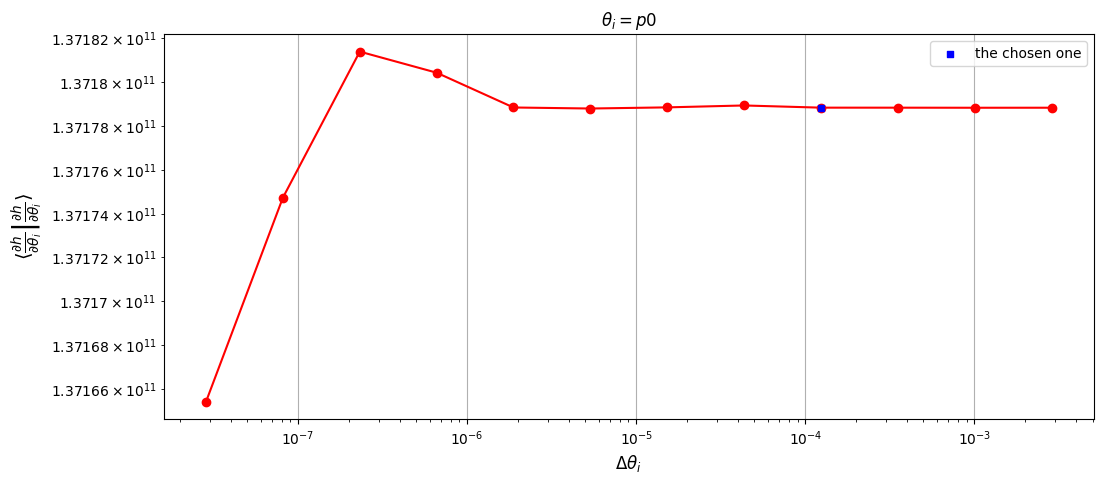

Gamma_ii for e0: 5828216223946.421
Gamma_ii for e0: 5828216200678.147
Gamma_ii for e0: 5828215942817.584
Gamma_ii for e0: 5828209309675.667
Gamma_ii for e0: 5828234534318.649
Gamma_ii for e0: 5828222896122.808
Gamma_ii for e0: 5828270450234.473
Gamma_ii for e0: 5827966277162.876
Gamma_ii for e0: 5827187888858.611
Gamma_ii for e0: 5828715156537.47
Gamma_ii for e0: 5826805914250.284
Gamma_ii for e0: 5821940149824.392
[np.float64(3.992349054380069e-09), np.float64(4.424348136831436e-08), np.float64(1.1381097631446104e-06), np.float64(4.328007535367787e-06), np.float64(1.9968686938070125e-06), np.float64(8.159214997156823e-06), np.float64(5.219197523304044e-05), np.float64(0.00013357872083598007), np.float64(0.0002620247580884819), np.float64(0.0003276653307631584), np.float64(0.0008357633882648802)]
0


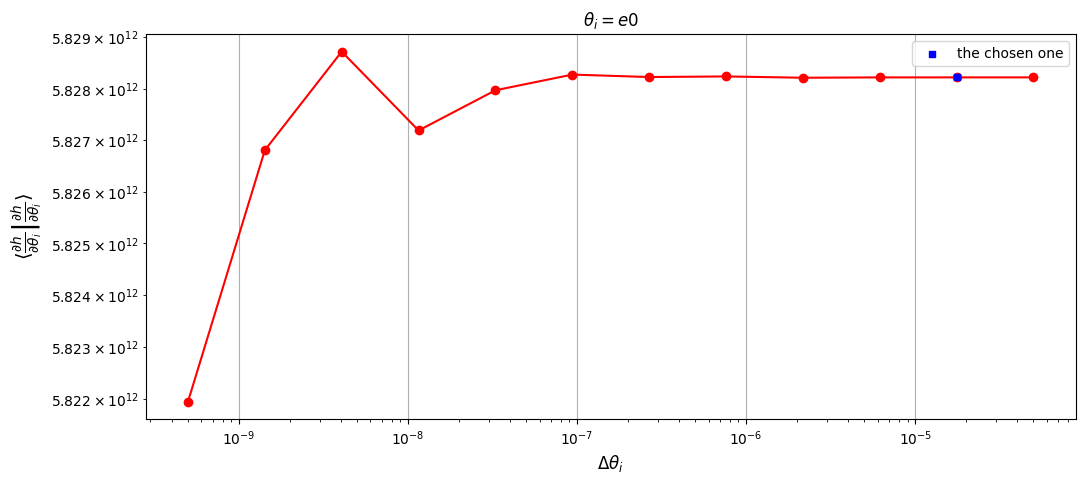

stable deltas: {'m1': 1.5199110829529339, 'm2': 0.12328467394420663, 'a': 3.160072560793623e-05, 'p0': 0.00012372168800293384, 'e0': 1.755595867107567e-05}
Time taken to compute stable deltas is 19.151270866394043 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 1.4521608352661133 seconds
[FISHER] array([[ 3.05980207e+01, -1.22916633e+03,  1.39027486e+06,
         2.04853884e+06,  1.32502368e+07],
       [-1.22916633e+03,  4.95732389e+04, -5.61925488e+07,
        -8.23675633e+07, -5.28142466e+08],
       [ 1.39027486e+06, -5.61925488e+07,  6.38356049e+10,
         9.32154969e+10,  5.94929056e+11],
       [ 2.04853884e+06, -8.23675633e+07,  9.32154969e+10,
         1.37178841e+11,  8.85524606e+11],
       [ 1.32502368e+07, -5.28142466e+08,  5.94929056e+11,
         8.85524606e+11,  5.82821620e+12]])
[FISHER_IS_PD] True
[FISHER_INV] array([[ 1.40396906e+06, -3.42521906e+03,  2.19232896e+00,
        -2.

/home/svu/e1583490/bias_inference_emri/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Sampling:   0%|          | 0/2999 [00:00<?, ?it/s]

/home/svu/e1583490/packages_to_install/parismc/parismc/sampler.py:1198: RuntimeWarning: divide by zero encountered in log
  logZ = c_term - np.log(Nsum) + np.log(wsum)
/home/svu/e1583490/packages_to_install/parismc/parismc/sampler.py:1198: RuntimeWarning: invalid value encountered in scalar add
  logZ = c_term - np.log(Nsum) + np.log(wsum)
Detected problematic log_density (NaN or Inf) 1 times. Check your implementation.
Detected problematic log_density (NaN or Inf) 1000 times. Check your implementation.
Detected problematic log_density (NaN or Inf) 2000 times. Check your implementation.


waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (np.float64(980605.6429823317), np.float64(10045.970428322638), np.float64(0.874155785207209), np.float64(28.907577910094645), np.float64(0.501312514694438), np.float64(1.0), np.float64(33.1765439), np.float64(1.04719755), np.float64(0.785398163), np.float64(0.628318531), np.float64(0.523598776), np.float64(0.1), np.float64(0.2), np.float64(0.3), 0.95, False, False, False, True, 0.0, 0.0)
SNR:  31.907688690553723
Body is not plunging, Fisher should be stable.
waveform shape: (3, 788953)
wave ndim: 2
Computing SNR for parameters: (np.float64(980605.6429823317), np.float64(10045.970428322638), np.float64(0.874155785207209), np.float64(28.907577910094645), np.float64(0.501312514694438), np.float64(1.0), np.float64(33.1765439), np.float64(1.04719755), np.float64(0.785398163), np.float64(0.628318531), np.float64(0.523598776), np.float64(0.1), np.float64(0.2), np.float64(0.3), 0.95, False, False, False, True, 0.0, 0.0)
Wa

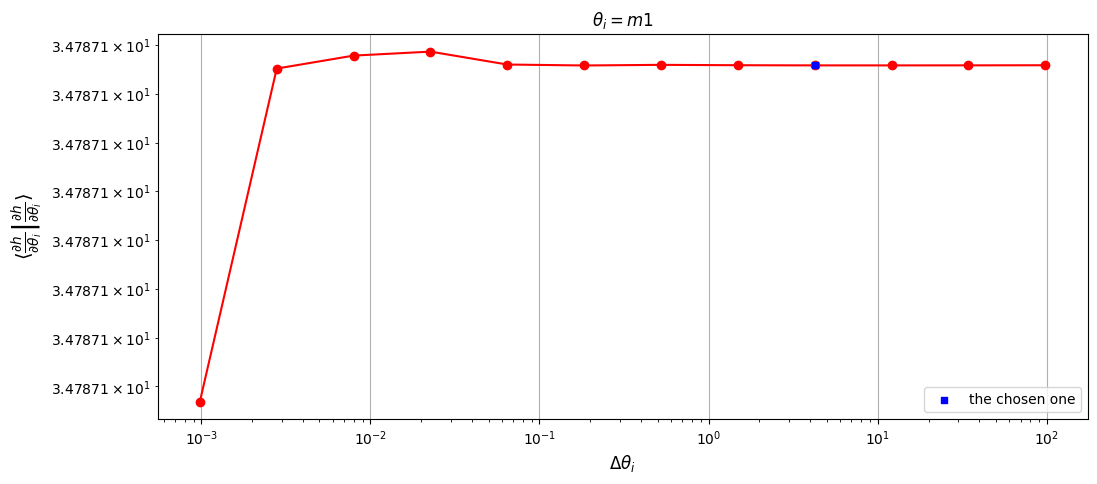

Gamma_ii for m2: 54096.696115693216
Gamma_ii for m2: 54096.69611379623
Gamma_ii for m2: 54096.69611035657
Gamma_ii for m2: 54096.696109848184
Gamma_ii for m2: 54096.696101422946
Gamma_ii for m2: 54096.696081580296
Gamma_ii for m2: 54096.696168978604
Gamma_ii for m2: 54096.69643475009
Gamma_ii for m2: 54096.696043099524
Gamma_ii for m2: 54096.70211790596
Gamma_ii for m2: 54096.699296741936
Gamma_ii for m2: 54096.66633017531
[np.float64(3.5066608599894064e-11), np.float64(6.358351392449285e-11), np.float64(9.397721986309508e-12), np.float64(1.5574405430034695e-10), np.float64(3.667996582539819e-10), np.float64(1.6155941912506578e-09), np.float64(4.912896798768426e-09), np.float64(7.239824152779451e-09), np.float64(1.122953192593518e-07), np.float64(5.2150391067229597e-08), np.float64(6.094010752417289e-07)]
2


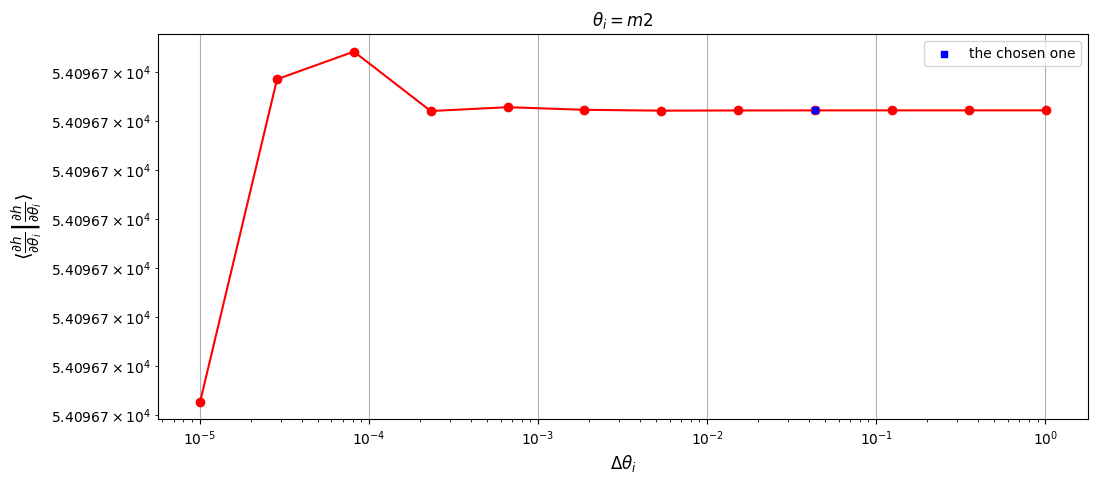

Gamma_ii for a: 69087466066.90294
Gamma_ii for a: 69087451750.73514
Gamma_ii for a: 69087600229.90634
Gamma_ii for a: 69087815840.66127
Gamma_ii for a: 69087767511.67648
Gamma_ii for a: 69088786972.32863
Gamma_ii for a: 69084714495.9345
Gamma_ii for a: 69101126271.33105
Gamma_ii for a: 69092165168.40877
Gamma_ii for a: 69036333115.39708
Gamma_ii for a: 69075511216.7492
Gamma_ii for a: 66885256070.82482
[np.float64(2.0721806114018364e-07), np.float64(2.149143561355606e-06), np.float64(3.1208217006867987e-06), np.float64(6.99530271821553e-07), np.float64(1.4755804766896532e-05), np.float64(5.894902257103746e-05), np.float64(0.00023750373231426838), np.float64(0.00012969781595995346), np.float64(0.0008087343358512778), np.float64(0.0005671778704495103), np.float64(0.03274645676178803)]
0


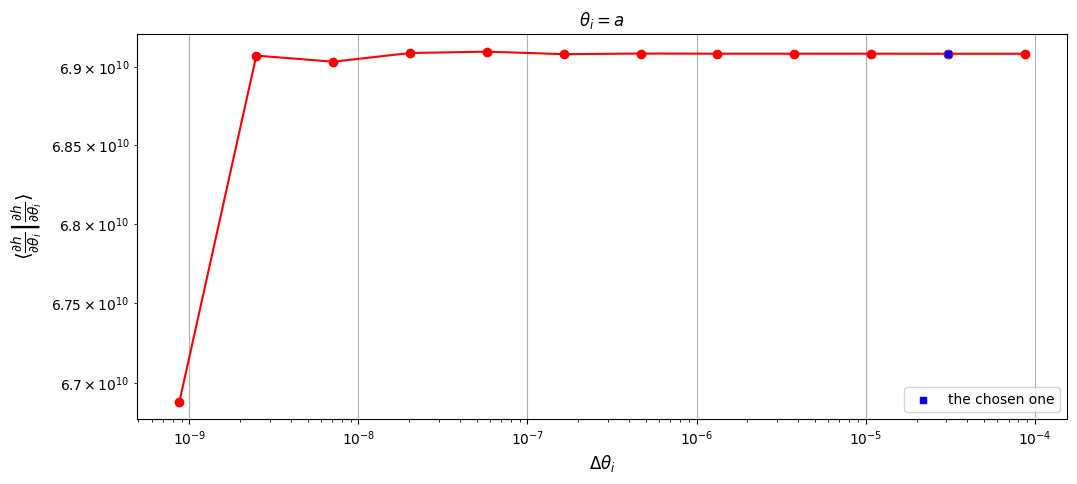

Gamma_ii for p0: 147303948068.33252
Gamma_ii for p0: 147303947313.2798
Gamma_ii for p0: 147303946962.3558
Gamma_ii for p0: 147303941669.74902
Gamma_ii for p0: 147303939942.00446
Gamma_ii for p0: 147303929314.77237
Gamma_ii for p0: 147304804522.67892
Gamma_ii for p0: 147304328954.51093
Gamma_ii for p0: 147302390717.472
Gamma_ii for p0: 147295223630.9314
Gamma_ii for p0: 147307494466.75394
Gamma_ii for p0: 147254787850.74423
[np.float64(5.125814671952992e-09), np.float64(2.3823121372475568e-09), np.float64(3.592983813611535e-08), np.float64(1.172911307430969e-08), np.float64(7.214493283116983e-08), np.float64(5.941475632048577e-06), np.float64(3.2284738091175032e-06), np.float64(1.3158218474932935e-05), np.float64(4.865796978282546e-05), np.float64(8.330082503242704e-05), np.float64(0.0003579280292273241)]
1


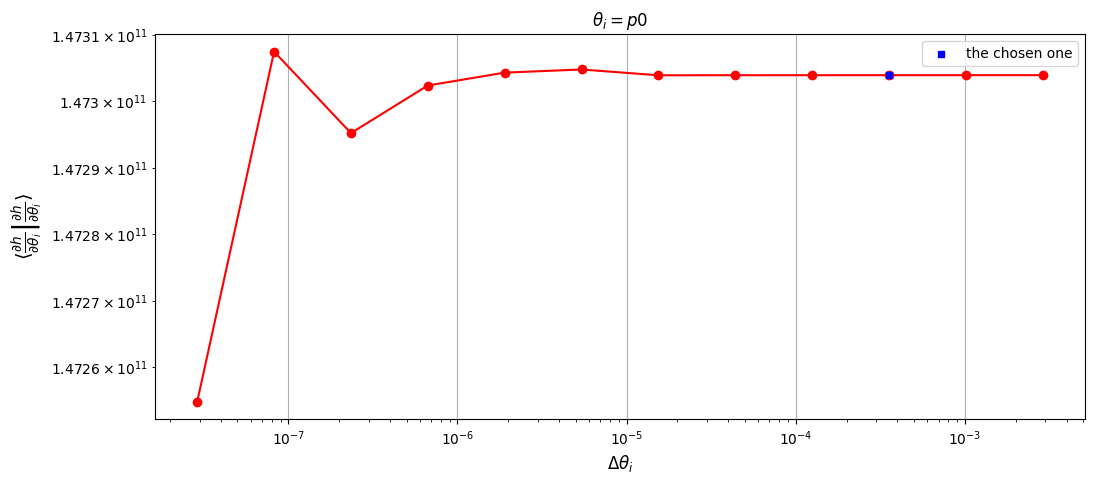

Gamma_ii for e0: 6362847891066.952
Gamma_ii for e0: 6362847759676.358
Gamma_ii for e0: 6362848212437.988
Gamma_ii for e0: 6362852422905.38
Gamma_ii for e0: 6362856370225.124
Gamma_ii for e0: 6362924003216.37
Gamma_ii for e0: 6362835735979.496
Gamma_ii for e0: 6363088999262.355
Gamma_ii for e0: 6362824475453.82
Gamma_ii for e0: 6359115708190.905
Gamma_ii for e0: 6356021731650.946
Gamma_ii for e0: 6342206724128.231
[np.float64(2.0649652280331014e-08), np.float64(7.115706909332864e-08), np.float64(6.61726394351764e-07), np.float64(6.203691415402741e-07), np.float64(1.0629231342682422e-05), np.float64(1.3872311110422775e-05), np.float64(3.9801939417904524e-05), np.float64(4.157333108207255e-05), np.float64(0.0005832205975019348), np.float64(0.0004867787856281194), np.float64(0.0021782650934661528)]
0


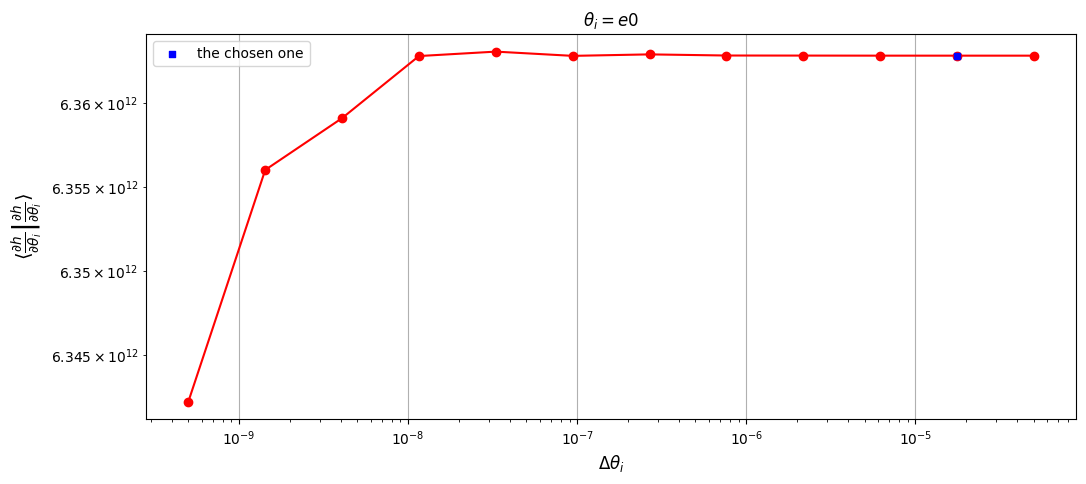

stable deltas: {'m1': 4.244807739353475, 'm2': 0.04348660782102844, 'a': 3.069328567435893e-05, 'p0': 0.00035638613171627687, 'e0': 1.760204357853714e-05}
Time taken to compute stable deltas is 19.263808727264404 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 1.4539315700531006 seconds
[FISHER] array([[ 3.47870766e+01, -1.36919772e+03,  1.54245714e+06,
         2.26345155e+06,  1.47658048e+07],
       [-1.36919772e+03,  5.40966961e+04, -6.10700606e+07,
        -8.91666269e+07, -5.76813855e+08],
       [ 1.54245714e+06, -6.10700606e+07,  6.90874518e+10,
         1.00504214e+11,  6.47236099e+11],
       [ 2.26345155e+06, -8.91666269e+07,  1.00504214e+11,
         1.47303947e+11,  9.59088325e+11],
       [ 1.47658048e+07, -5.76813855e+08,  6.47236099e+11,
         9.59088325e+11,  6.36284776e+12]])
[FISHER_IS_PD] True
[FISHER_INV] array([[ 1.25764217e+06, -3.16236197e+03,  2.03280334e+00,
        -2.2

In [ ]:
def main():

    cfg = Config()
    signal_param_array = cfg.params
    optimizer = cfg.optimizer
    target_func = cfg.target_func
    base_dir =cfg.basedir
    timestamp = time.strftime('%Y%m%d-%H%M%S')
    #add starting point#
    
    parameter_selected = cfg.parameter_selected
    run_type = cfg.run_type
    dt = cfg.dt
    T = cfg.T
    chi2= cfg.chi2
    dev_1 = cfg.dev_1
    dev_2 = cfg.dev_2
    
    startingpoints = cfg.startingpoints
    id = int(startingpoints[-5])
    starting_point =  load_startingpoint_param_array(startingpoints)
    
    emri_kwargs = {"T": T, "dt": dt,'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
    add_kwargs = {'chi2': chi2,'evolve_1PA': True,'evolve_primary': False,'evolve_2PA': False,'deviation_included': True,
                   'dev_1': dev_1, 'dev_2': dev_2}
    
    if target_func in ('optimal_snr', 'optimal_snr_phase_max','time_max'):
        
        ctx = prepare_true_waveform(signal_param_array, emri_kwargs, add_kwargs, use_gpu=True)
    else:
        (
            m1, m2, a, p0, e0, Y0,
            dist, qS, phiS, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0, 
        ) = signal_param_array
        ctx = {
            'm1': m1, 'm2': m2, 'a': a, 'p0': p0, 'e0': e0, 'Y0': Y0,
            'dist': dist, 'qS': qS, 'phiS': phiS, 'qK': qK, 'phiK': phiK,
            'Phi_phi0': Phi_phi0, 'Phi_theta0': Phi_theta0, 'Phi_r0': Phi_r0,
            'dt': dt, 'T': T, 'chi2': chi2, 'dev_1': dev_1, 'dev_2': dev_2
        }
    
    for k in ['m1', 'm2', 'a', 'p0', 'e0', 'Y0', 'dist', 'qS', 'phiS', 'qK', 'phiK', 'Phi_phi0', 'Phi_theta0', 'Phi_r0', 'chi2','dt', 'T','dev_1','dev_2']:
        assert k in ctx, f"Missing {k} in 1PA context"
    
    # Initial theta from startingpoint array if available, else from signal row
    if cfg.run_type == '0pa_vs_1pa' and cfg.parameter_selected == "intrinsic":
        #theta_names = ['m1', 'm2', 'a', 'p0', 'e0']
        if starting_point is not None:
            theta0 = np.array([starting_point['m1'], starting_point['m2'], starting_point['a'], starting_point['p0'], starting_point['e0']], dtype=float)
        else:
            theta0 = np.array([ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0']], dtype=float)
        ndim = 5
    elif cfg.run_type == '0pa_vs_1pa_dev' and cfg.parameter_selected == "intrinsic":
        #assert "Not implemented yet: deviation_included=True with intrinsic-only inference"
        #theta_names = ['m1', 'm2', 'a', 'p0', 'e0','dev_1','dev_2']
        if starting_point is not None:
            theta0 = np.array([starting_point['m1'], starting_point['m2'], starting_point['a'], starting_point['p0'],
                                starting_point['e0'], starting_point['dev_1'], starting_point['dev_2']], dtype=float)
        else:
            theta0 = np.array([ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0'], ctx['dev_1'], ctx['dev_2']], dtype=float)
        ndim = 7
    elif cfg.run_type == '0pa_vs_1pa' and cfg.parameter_selected == "extrinsic":
        #theta_names = ['m1', 'm2', 'a', 'p0', 'e0','qS', 'phiS', 'Phi_phi0', 'Phi_r0']
        if starting_point is not None:
            theta0 = np.array([starting_point['m1'], starting_point['m2'], starting_point['a'], starting_point['p0'], 
                               starting_point['e0'], starting_point['qS'], starting_point['phiS'], starting_point['Phi_phi0'],
                                 starting_point['Phi_r0']], dtype=float)
        else:
            theta0 = np.array([ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0'], ctx['qS'],
                                ctx['phiS'], ctx['Phi_phi0'], ctx['Phi_r0']], dtype=float)
        ndim = 9
    
    elif cfg.run_type == '0pa_vs_1pa_dev' and cfg.parameter_selected == "extrinsic":
        #theta_names = ['m1', 'm2', 'a', 'p0', 'e0','qS', 'phiS', 'Phi_phi0', 'Phi_r0','dev_1','dev_2']
        if starting_point is not None:
            theta0 = np.array([starting_point['m1'], starting_point['m2'], starting_point['a'],
                                starting_point['p0'], starting_point['e0'], starting_point['qS'],
                                starting_point['phiS'], starting_point['Phi_phi0'], starting_point['Phi_r0'],
                                  starting_point['dev_1'], starting_point['dev_2']], dtype=float)
        else:
            theta0 = np.array([ctx['m1'], ctx['m2'], ctx['a'], ctx['p0'], ctx['e0'],
                                ctx['qS'], ctx['phiS'], ctx['Phi_phi0'], ctx['Phi_r0'], ctx['dev_1'], ctx['dev_2']], dtype=float)
        ndim = 11
    
    else:  raise ValueError(f"Unsupported run_type {cfg.run_type} with parameter_selected {cfg.parameter_selected}")
    
    # Objective setup with tracker for fallback support
    #no 1PA for analysis manifold
    add_kwargs['evolve_1PA'] = False
    
    phase_max_flag = (target_func == 'optimal_snr_phase_max')
    raw_objective = objective_factory(
        target_func=target_func,
        ctx=ctx,
        phase_max=phase_max_flag,
        infer_deviation_included= run_type == '0pa_vs_1pa_dev',
        only_intrinsic_params= parameter_selected == "intrinsic",
        add_kwargs=add_kwargs,
    )
    tracker = ObjectiveTracker(theta0)
    def tracked_objective(theta: np.ndarray) -> float:
        val = float(raw_objective(np.asarray(theta, dtype=float)))
        tracker.update(theta, val)
        return val
    try:
        tracked_objective(theta0)
    except Exception as exc:
        print(f"[WARN] Initial objective evaluation failed at theta0: {exc}")
        tracker._best_score = float('-inf')
        
    objective = tracked_objective
    result = None
    if optimizer == 'nelder-mead':
            try:
                # Constrain search to remain within relative deviation of original (ctx-based) parameters
                tol = 1e-6 #1e-8 1pa emri #1e-6
                theta_ref = theta0.copy()
                def bounded_objective(theta: np.ndarray) -> float:
                    denom = np.abs(theta_ref) #+ 1e-30
                    rel = np.abs(np.asarray(theta) - theta_ref) / denom
                    if np.any(rel > tol):
                        return 1e7
                    # Nelder–Mead minimizes; convert larger-is-better score to loss
                    score_val = objective(theta)
                    return -float(score_val)
                result = nelder_mead_optimize(
                    theta0,
                    bounded_objective,
                    xatol=cfg.nm_xatol,
                    fatol=cfg.nm_fatol,
                )
                best_score = -float(result.fun)
                tracker.update(result.x, best_score)
    
                # Per-index output directory named with best score and optimized point
                
                _opt_vals = result.x
                
                _vals_str = '_'.join(f"{v:.6e}" for v in _opt_vals)
                nealder_mead_dir = os.path.join(base_dir, f"nelder_mead_{target_func}_run_id_{id}")
                idx_dir = os.path.join(nealder_mead_dir, f"{best_score:.12g}_{_vals_str}")
                os.makedirs(idx_dir, exist_ok=True)
                out = {
                    'optimizer': 'nelder-mead',
                    'target_func': cfg.target_func,
                    'theta0': theta0.tolist(),
                    'x': result.x.tolist(),
                    'fun': float(result.fun),
                    'best_score': best_score,
                    'success': bool(result.success),
                    'snr_ref_1pa': float(ctx.get('snr', np.nan)),
                }
                out_name = os.path.join(idx_dir, f"opt_nelder-mead_{cfg.target_func}_{timestamp}_id_{id}.json")
                with open(out_name, 'w') as f:
                    json.dump(out, f, indent=2)
                print(f"Saved result: {out_name}")
                print(f"[RESULT] Best loss (=-score): {out['fun']:.6e}")
                print(f"[RESULT] Best score: {out['best_score']:.6e}")
                print(f"[RESULT] Best point: {out['x']}")
                if not result.success:
                    print(f"[WARN] Nelder-Mead optimization did not converge: {result.message}")
    
                match ndim:
                    case 5:
                        print(f"Optimized (m1, m2, a, p0, e0): {result.x}")
                        result_array = np.copy(starting_point)
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_nelder_mead_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case 7:
                        print(f"Optimized (m1, m2, a, p0, e0, dev_1, dev_2): {result.x}")
                        result_array = np.copy(starting_point)
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'dev_1', 'dev_2']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_nelder_mead_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case 9:
                        print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0): {result.x}")
                        result_array = np.copy(starting_point)
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_nelder_mead_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case 11:
                        print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2): {result.x}")
                        result_array = np.copy(starting_point)
                        starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev_1', 'dev_2']
                        for i, key in enumerate(starting_point_keys):
                            result_array[key] = result.x[i]
                        print(f"Optimized parameters as array: {result_array}")
                        np.save(os.path.join(idx_dir, f"results_nelder_mead_{id+1}_time_{timestamp}.npy"), result_array)
                        np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                    case _:
                        print(f"Optimized parameters: {result.x}")

                add_kwargs['evolve_1PA'] = False
                add_kwargs['dev_1']=starting_point_keys['dev_1'] if 'dev_1' in starting_point_keys else add_kwargs.get('dev_1', 0.0)
                add_kwargs['dev_2']=starting_point_keys['dev_2'] if 'dev_2' in starting_point_keys else add_kwargs.get('dev_2', 0.0)
                print("Overlap of the best point:",calculate_detection_overlap_0pa_vs_1pa(
                        starting_point_keys['m1'], starting_point_keys['m2'], starting_point_keys['a'], starting_point_keys['p0'], starting_point_keys['e0'], ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                        starting_point_keys['Phi_phi0'], ctx['Phi_theta0'], starting_point_keys['Phi_r0'],add_kwargs,
                        maximize_phase=False,**ctx) )
                
                Config.save_results_with_config(
                                        cfg=cfg,
                                        results=out,
                                        save_dir=idx_dir,
                                        filename_prefix=f"opt_nelder_mead_{cfg.target_func}_id_{id}"
                                    )
    
            except Exception as exc:
                print(f"[ERROR] Nelder-Mead optimization failed: {exc}")
                
    elif optimizer == 'paris':
        # --- PARIS Optimization Block ---

        try:
        # if True:
            # ---------------------------
            # Fisher prior computation
            # ---------------------------
            try:
                import cupy as cP
                USE_GPU = True
            except ImportError:
                USE_GPU = False

            try:
                add_kwargs['evolve_1PA'] = False
                Q, b, fisher_meta = compute_fisher_parallelotope(
                    ctx=ctx,
                    params_to_infer=cfg.param_names_to_infer,
                    fisher_params=signal_param_array,
                    use_gpu=USE_GPU,
                    prior_sigma_range=float(cfg.prior_sigma_range),
                    using_evec=cfg.using_evec,
                    additional_kwargs=add_kwargs,
                    build_waveform_response= build_waveform_response

                )
                fisher_ok = True

            except Exception as e:
                raise RuntimeError(f"[FATAL] Fisher prior failed: {e}") from e

            # ---------------------------
            # Directory setup
            # ---------------------------
            idx_dir = os.path.join(base_dir, f"paris_{cfg.target_func}")
            os.makedirs(idx_dir, exist_ok=True)

            savepath = os.path.join(idx_dir, f"paris_results_{cfg.target_func}_{timestamp}_id_{id}")
            lhs_seed_rel = "lhs_seed"
            lhs_seed_dir = os.path.join(idx_dir, lhs_seed_rel)

            # ---------------------------
            # Run PARIS optimizer
            # ---------------------------
            sampler, prior_transform, ext_points = run_paris(
                ndim=ndim,
                prior_center=theta0,
                score_func=objective,
                spread_scale=float(cfg.spread_scale),
                savepath=savepath,
                seed_cloud=int(cfg.seed_cloud),
                seed_jitter=1e-10,
                target_kind=cfg.target_func,
                lhs_save_dir=lhs_seed_dir,
                affine_Q=Q if fisher_ok else None,
                affine_b=b if fisher_ok else None,
                use_ellipse=bool(fisher_meta.get("using_evec", False)),
            )

            # ---------------------------
            # Extract best point
            # ---------------------------
            def extract_best_point():
                try:
                    pts = sampler.searched_points_list
                    logs = sampler.searched_log_densities_list

                    if not pts or not logs:
                        raise ValueError("Empty PARIS search results")

                    best_unit = pts[0][int(np.argmax(logs[0]))]
                    return prior_transform(best_unit)

                except Exception as e:
                    print(f"[WARN] Best extraction failed: {e}, using fallback")

                    fallback = getattr(sampler, "_fallback_best_point", None)
                    if fallback is None:
                        raise RuntimeError("No fallback best point available") from e

                    return np.asarray(fallback, dtype=float)

            best_theta = extract_best_point()

            if best_theta is None:
                print("[WARN] Using starting point as fallback")
                best_theta = theta0

            best_theta = np.asarray(best_theta, dtype=float)

            # Transform if still in unit cube
            if np.all((best_theta >= 0.0) & (best_theta <= 1.0)):
                best_theta = prior_transform(best_theta)

            best_val = float(objective(best_theta))

            # ---------------------------
            # Local polishing (Gaussian steps)
            # ---------------------------
            best_fit_points = signal_param_array
            if cfg.parameter_selected == "intrinsic":
                if cfg.run_type == '0pa_vs_1pa':
                    best_fit_points[0:5] = best_theta

                elif cfg.run_type == '0pa_vs_1pa_dev':
                    best_fit_points[0:5] = best_theta
                    add_kwargs['dev_1'] = best_theta[5]
                    add_kwargs['dev_2'] = best_theta[6]
                else:
                    print(f"[WARN] Unsupported run_type {cfg.run_type} for best_fit_points assignment with parameter_selected=intrinsic")
            else:
                if cfg.run_type == '0pa_vs_1pa':
                    best_fit_points[0:5] = best_theta[0:5]
                    best_fit_points[7:9] = best_theta[5:7]
                    best_fit_points[11] = best_theta[7]
                    best_fit_points[13] = best_theta[8]

                elif cfg.run_type == '0pa_vs_1pa_dev':
                    best_fit_points[0:5] = best_theta[0:5]
                    best_fit_points[7:9] = best_theta[5:7]
                    best_fit_points[11] = best_theta[7]
                    best_fit_points[13] = best_theta[8]
                    add_kwargs['dev_1'] = best_theta[9]
                    add_kwargs['dev_2'] = best_theta[10]
                else:
                    print(f"[WARN] Unsupported run_type {cfg.run_type} for best_fit_points assignment with parameter_selected=extrinsic")


            Qp, bp, _ = compute_fisher_parallelotope(
                       ctx=ctx,
                    params_to_infer=cfg.param_names_to_infer,
                    fisher_params=best_fit_points,
                    use_gpu=USE_GPU,
                    prior_sigma_range=float(cfg.prior_sigma_range),
                    using_evec=cfg.using_evec,
                    additional_kwargs=add_kwargs,
                    build_waveform_response= build_waveform_response
                )

            cov = covariance_from_fisher_parallelotope(
                Qp, bp, prior_sigma_range=float(cfg.prior_sigma_range)
            )

            rng = np.random.default_rng()
            ndim_local = len(best_theta)

            for _ in range(500):
                step = rng.multivariate_normal(
                    mean=np.zeros(ndim_local),
                    cov=1e-5 * cov,
                )

                cand = _clip_physical_params_intrinsic(best_theta + step)
                val = float(objective(cand))

                if val > best_val:
                    best_theta, best_val = cand, val

            tracker.update(best_theta, best_val)

            print(f"[POLISH] Final best score: {best_val:.6e}")
            print(f"[POLISH] Final best point: {best_theta.tolist()}")

            # ---------------------------
            # Rename directory based on result
            # ---------------------------
            vals_str = ",".join(f"{float(v):.12g}" for v in best_theta)
            new_idx_dir = os.path.join(base_dir, f"{best_val:.12g}_{vals_str}")

            if os.path.abspath(new_idx_dir) != os.path.abspath(idx_dir):
                os.rename(idx_dir, new_idx_dir)
                idx_dir = new_idx_dir
                savepath = os.path.join(idx_dir, os.path.basename(savepath))

            lhs_seed_dir = os.path.join(idx_dir, lhs_seed_rel)

            # ---------------------------
            # Save outputs
            # ---------------------------
            out = {
                "optimizer": "PARIS",
                "target_func": cfg.target_func,
                "theta0": theta0.tolist(),
                "snr_ref_2pa": float(ctx.get("snr", np.nan)),
                "savepath": savepath,
                "fisher_prior": True,
                "fisher_meta": fisher_meta,
                "best_point": best_theta.tolist(),
                "best_score": best_val,
                "lhs_seed_dir": lhs_seed_dir,
            }

            json_path = os.path.join(idx_dir, f"opt_PARIS_{cfg.target_func}_{timestamp}.json")
            with open(json_path, "w") as f:
                json.dump(out, f, indent=2)

            np.save(
                os.path.join(idx_dir, f"score_PARIS_{cfg.target_func}_{timestamp}.npy"),
                np.array([best_val], dtype=float),
            )
            Config.save_results_with_config(
            cfg=cfg,
            results=out,
            save_dir=idx_dir,
            filename_prefix=f"opt_PARIS_{cfg.target_func}_id_{id}")

            

            match ndim:
                        case 5:
                            print(f"Optimized (m1, m2, a, p0, e0): {result.x}")
                            result_array = np.copy(starting_point)
                            starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0']
                            for i, key in enumerate(starting_point_keys):
                                result_array[key] = best_theta[i]
                            print(f"Optimized parameters as array: {result_array}")
                            np.save(os.path.join(idx_dir, f"results_paris_{id+1}_time_{timestamp}.npy"), result_array)
                            np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                        case 7:
                            print(f"Optimized (m1, m2, a, p0, e0, dev_1, dev_2): {result.x}")
                            result_array = np.copy(starting_point)
                            starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'dev_1', 'dev_2']
                            for i, key in enumerate(starting_point_keys):
                                result_array[key] = best_theta[i]
                            print(f"Optimized parameters as array: {result_array}")
                            np.save(os.path.join(idx_dir, f"results_paris_{id+1}_time_{timestamp}.npy"), result_array)
                            np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                        case 9:
                            print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0): {result.x}")
                            result_array = np.copy(starting_point)
                            starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0']
                            for i, key in enumerate(starting_point_keys):
                                result_array[key] = best_theta[i]
                            print(f"Optimized parameters as array: {result_array}")
                            np.save(os.path.join(idx_dir, f"results_paris_{id+1}_time_{timestamp}.npy"), result_array)
                            np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                        case 11:
                            print(f"Optimized (m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0, dev_1, dev_2): {result.x}")
                            result_array = np.copy(starting_point)
                            starting_point_keys = ['m1', 'm2', 'a', 'p0', 'e0', 'qS', 'phiS', 'Phi_phi0', 'Phi_r0', 'dev_1', 'dev_2']
                            for i, key in enumerate(starting_point_keys):
                                result_array[key] = best_theta  [i]
                            print(f"Optimized parameters as array: {result_array}")
                            np.save(os.path.join(idx_dir, f"results_paris_{id+1}_time_{timestamp}.npy"), result_array)
                            np.save(os.path.join(idx_dir, f"starting_point_{id+1}.npy"), result_array)
                        case _:
                            print(f"Optimized parameters: {result.x}")

            add_kwargs['evolve_1PA'] = False
            add_kwargs['dev_1']=starting_point_keys['dev_1'] if 'dev_1' in starting_point_keys else add_kwargs.get('dev_1', 0.0)
            add_kwargs['dev_2']=starting_point_keys['dev_2'] if 'dev_2' in starting_point_keys else add_kwargs.get('dev_2', 0.0)
            print("Overlap of the best point:",calculate_detection_overlap_0pa_vs_1pa(
                    starting_point_keys['m1'], starting_point_keys['m2'], starting_point_keys['a'], starting_point_keys['p0'], starting_point_keys['e0'], ctx['Y0'],ctx['dist'],qS,phiS, ctx['qK'], ctx['phiK'], 
                    starting_point_keys['Phi_phi0'], ctx['Phi_theta0'], starting_point_keys['Phi_r0'],add_kwargs,
                    maximize_phase=False,
                    **ctx) )

        # ---------------------------
        # Global failure handler
        # ---------------------------
        except Exception as exc:
            print(f"[WARN] PARIS optimization failed: {exc}")
            

if __name__ == "__main__":
    main()